# VHH HEFT predictions

Interactive notebook for **$W^\pm HH$** and **$ZHH$** using bundled JSON inputs (`pdf_alpha_s_covariance.json`, `scale_coefficients.json`).

| Section | Purpose |
|---------|---------|
| **Setup** | Load analysis for a process / energy |
| **Spot check** | Print $\sigma_{\mathrm{LO}}$, $\sigma_{\mathrm{NNLO}}$, $K$ at chosen $\kappa$ |
| **Scans & plots** | $\kappa$ scans with PDF+$\alpha_s$ and scale bands (saved under `Results/Plots/`) |
| **SM enhancement** | $\sigma_{\mathrm{LO,NNLO}}/\sigma_{\mathrm{LO,NNLO}}^{\mathrm{SM}}$ vs $\kappa$ (optional) |
| **Wilson tables** | Paper-style $\sigma_{\mathrm{NNLO}}$ at Wilson-interval min / SM / max (section 7) |

Run from the `Package/` directory.

In [1]:
import sys
from pathlib import Path

PACKAGE_ROOT = Path('.').resolve()
if str(PACKAGE_ROOT) not in sys.path:
    sys.path.insert(0, str(PACKAGE_ROOT))

import matplotlib.pyplot as plt
from vhh_predict import (
    collect_simulation_scan_points,
    format_prediction,
    load_analysis,
    predict,
    plots_dir,
    tables_dir,
    resolve_scan_axis,
    scan,
    scan_axes,
    scan_sm_enhancement,
    simulation_scan_arrays,
)
from vhh_predict.plots import X_LABELS, plot_kfactor_only, plot_sigma_nnlo_and_kfactor, plot_sm_enhancement

PLOTS_DIR = plots_dir()
TABLES_DIR = tables_dir()
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


## 1. Configuration

Set the options in the next cell, then run it once per session.

| Option | Description |
|--------|-------------|
| `PROCESS` | `WplusHH`, `WminusHH`, or `ZHH` |
| `ENERGY_TEV` | `13.6` or `14.0` (must match bundled `data/{Process}/…`) |
| `KAPPA` | Fixed κ point for spot check; see tuple layout below |
| `UNCERTAINTIES_AS_PERCENT` | Print scale/PDF bands as `%` in section 2 |
| `SAVE_PLOTS` | Write PNG figures to `Results/Plots/` |
| `SIGMA_INSET` | Zoom inset on σ panel in section 4 (left 1% of scan range) |
| `COMPARE_SIMULATION` | Compare to bundled MadGraph `.out` files in `data/{Process}/{energy}/Simulation/` (sections 2 & 4) |
| `PLOT_SM_ENHANCEMENT` | Run section 6 (σ/σ_SM scan) |

**κ tuple layout** (order matters):

| Process | `KAPPA` | Default for omitted component |
|---------|---------|-------------------------------|
| `WplusHH`, `WminusHH` | `(κ_λ, κ_W, κ_2W)` | — |
| `ZHH` | `(κ_λ, κ_Z, κ_2Z)` or `(κ_λ, κ_Z, κ_2Z, κ_t)` | `κ_t = 1` if omitted |

**Scan axes** (`scan_axis` in section 4; also used in section 6):

| Process | `scan_axes(PROCESS)` |
|---------|----------------------|
| `ZHH` | `kappa_lambda`, `kappa_z`, `kappa_2z`, `kappa_t` |
| `W±` | `kappa_lambda`, `kappa_w`, `kappa_2w` |

Aliases: `kappa_kt` → `kappa_t` (ZHH only).

In [2]:
PROCESS = 'ZHH'        # 'WplusHH' | 'WminusHH' | 'ZHH'
ENERGY_TEV = 14.0      # 13.6 or 14.0

# κ at the spot-check point (section 2):
#   W±:  (kappa_lambda, kappa_w, kappa_2w)
#   ZHH: (kappa_lambda, kappa_z, kappa_2z)  or add kappa_t as 4th element
KAPPA = (3.0, 1.0, 1.0)

UNCERTAINTIES_AS_PERCENT = True
SAVE_PLOTS = True
SIGMA_INSET = True             # section 4: zoom inset on σ panel
COMPARE_SIMULATION = True
PLOT_SM_ENHANCEMENT = True

analysis = load_analysis(PROCESS, ENERGY_TEV)
nn_label = analysis.nnlo_label

print(f'Process: {PROCESS} @ {ENERGY_TEV} TeV')
print(f'Available scan axes: {", ".join(scan_axes(PROCESS))}')

Process: ZHH @ 14.0 TeV
Available scan axes: kappa_lambda, kappa_z, kappa_2z, kappa_t


## 2. Spot check — print prediction

In [3]:
print(format_prediction(
    analysis,
    KAPPA,
    as_percent=UNCERTAINTIES_AS_PERCENT,
    compare_simulation=COMPARE_SIMULATION,
))

ZHH @ 14.0 TeV  κ=(3, 1, 1, 1)
  σ_LO   HEFT 0.734171  +0.81%/-1.07% (scale)  ±2.01% (PDF+αs)
  σ_NNLO  HEFT 0.944590  +2.03%/-1.65% (scale)  ±1.95% (PDF+αs)
  K      HEFT 1.286607  +1.53%/-1.35% (scale)  ±2.80% (PDF+αs)
             sim 0.740306  (diff -0.829% vs HEFT)
             sim 0.948605  (diff -0.423% vs HEFT)
             sim 1.28137  (diff +0.409% vs HEFT)


## 3. Structured output

In [4]:
p = predict(analysis, KAPPA)
{
    'sigma_LO': p.sigma_lo,
    'sigma_NNLO': p.sigma_nnlo,
    'K': p.k_factor,
    'sigma_NNLO_pdfas': p.sigma_nnlo_pdfas,
    'sigma_NNLO_scale_up': p.sigma_nnlo_scale_up,
    'sigma_NNLO_scale_down': p.sigma_nnlo_scale_down,
}

{'sigma_LO': 0.7341712066899999,
 'sigma_NNLO': 0.9445901024710002,
 'K': 1.2866073932940938,
 'sigma_NNLO_pdfas': 0.018403241593665177,
 'sigma_NNLO_scale_up': 0.0191581052693498,
 'sigma_NNLO_scale_down': 0.01557074581961504}

## 4. κ scan — σ$_{\mathrm{NNLO}}$ + $K$ (two panels)

Vary one κ component while the others stay fixed at `KAPPA` (with `κ_t=1` appended for ZHH if omitted).

- **Top panel:** σ$_{\mathrm{NNLO}}$ with PDF+α$_s$ (blue) and 7-point scale envelope (red hatch). Set `SIGMA_INSET = True` in section 1 for a zoom inset on the left 1% of the scan range.
- **Bottom panel:** $K = \sigma_{\mathrm{NNLO}}/\sigma_{\mathrm{LO}}$.
- Set `show_k_uncertainty=True` in the plot call to draw $K$ uncertainty bands.
- With `COMPARE_SIMULATION=True`, matching MadGraph central values are overlaid as orange circles.

Overlaying 1 simulation point(s) on scan plot


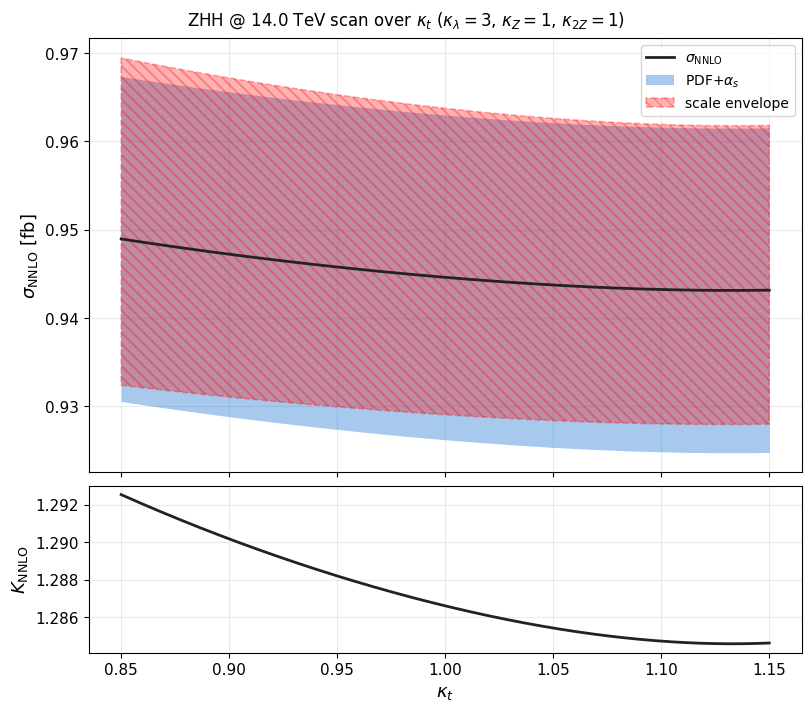

Saved /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO/Results/Plots/ZHH_14.0TeV_scan_kappa_t.png


In [5]:
fixed = list(KAPPA)
if PROCESS == 'ZHH' and len(fixed) == 3:
    fixed.append(1.0)

# --- scan settings (must be one of scan_axes(PROCESS)) ---
scan_axis = 'kappa_t'
scan_vmin, scan_vmax = 0.85, 1.15
scan_n_points = 400

_, scan_x_key = resolve_scan_axis(PROCESS, scan_axis)
scan_axis_label = X_LABELS[scan_x_key]

scan_data = scan(
    analysis,
    axis=scan_axis,
    vmin=scan_vmin,
    vmax=scan_vmax,
    n_points=scan_n_points,
    fixed_kappa=tuple(fixed),
)

sim_scan = None
if COMPARE_SIMULATION:
    sim_points = collect_simulation_scan_points(
        PROCESS,
        ENERGY_TEV,
        scan_axis,
        fixed_kappa=tuple(fixed),
        vmin=scan_vmin,
        vmax=scan_vmax,
    )
    sim_scan = simulation_scan_arrays(sim_points)
    if len(sim_scan['x']):
        print(f'Overlaying {len(sim_scan["x"])} simulation point(s) on scan plot')

_scan_idx, _ = resolve_scan_axis(PROCESS, scan_axis)
if PROCESS == 'ZHH':
    _kappa_names = [r'\lambda', 'Z', r'2Z', 't']
    fixed_title = ', '.join(
        rf'$\kappa_{{{_kappa_names[i]}}}={fixed[i]:g}$'
        for i in range(4)
        if i != _scan_idx
    )
else:
    _kappa_names = [r'\lambda', 'W', r'2W']
    fixed_title = ', '.join(
        rf'$\kappa_{{{_kappa_names[i]}}}={fixed[i]:g}$'
        for i in range(3)
        if i != _scan_idx
    )

sigma_k_path = PLOTS_DIR / f'{PROCESS}_{ENERGY_TEV}TeV_scan_{scan_x_key}.png'
plot_sigma_nnlo_and_kfactor(
    scan_data,
    title=f'{PROCESS} @ {ENERGY_TEV} TeV scan over {scan_axis_label} ({fixed_title})',
    nnlo_label=nn_label,
    show_k_uncertainty=False,
    sigma_inset=False,
    #sim_scan=sim_scan,
    output=sigma_k_path,
    save=SAVE_PLOTS,
)
plt.show()
if SAVE_PLOTS:
    print(f'Saved {sigma_k_path}')

## 5. K-factor only

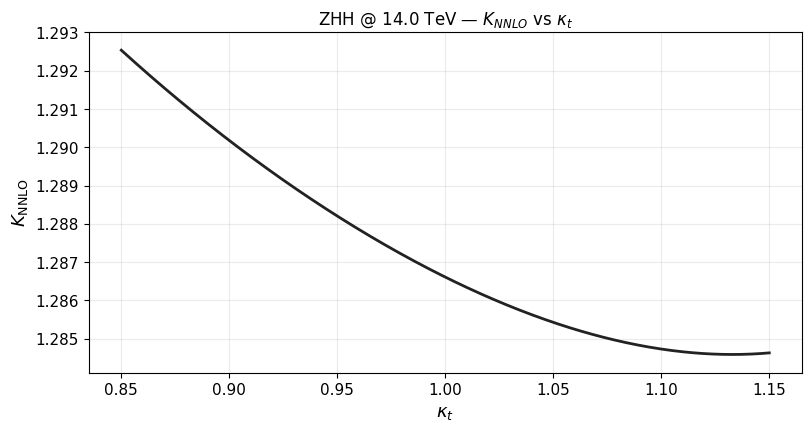

Saved /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO/Results/Plots/ZHH_14.0TeV_K_kappa_t.png


In [6]:
k_path = PLOTS_DIR / f'{PROCESS}_{ENERGY_TEV}TeV_K_{scan_x_key}.png'
plot_kfactor_only(
    scan_data,
    title=f'{PROCESS} @ {ENERGY_TEV} TeV — $K_{{{nn_label}}}$ vs {scan_axis_label}',
    nnlo_label=nn_label,
    show_uncertainty=False,
    output=k_path,
    save=SAVE_PLOTS,
)
plt.show()
if SAVE_PLOTS:
    print(f'Saved {k_path}')

## 6. SM enhancement — $\sigma/\sigma_{\mathrm{SM}}$ (LO and NNLO)

HEFT cross section relative to the SM point $\kappa=(1,1,1)$ for W$^\pm$HH or $(1,1,1,1)$ for ZHH.

SM reference @ ZHH 14.0 TeV: σ_LO=0.305501 fb, σ_NNLO=0.417333 fb


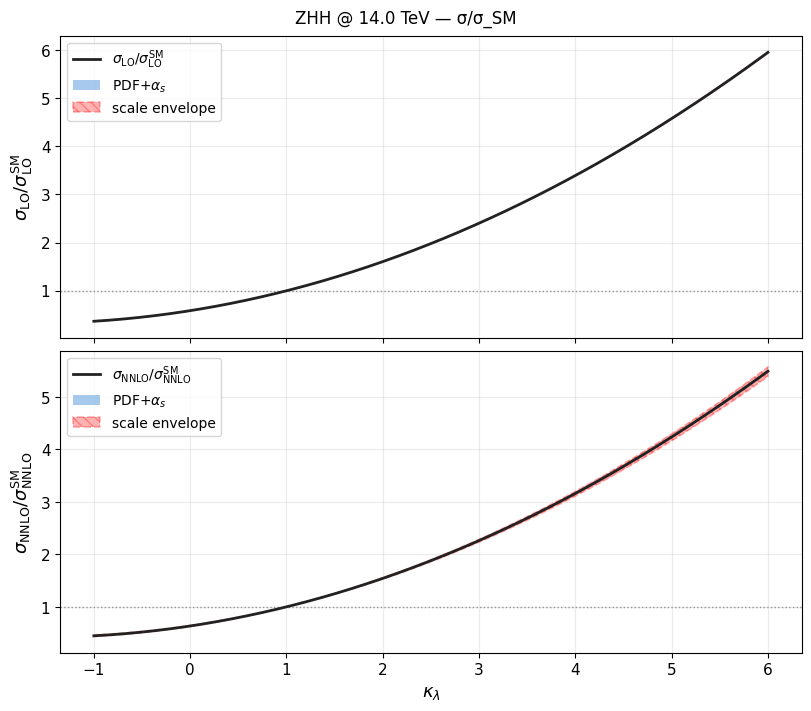

Saved /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO/Results/Plots/ZHH_14.0TeV_SM_enhancement.png


In [7]:
if PLOT_SM_ENHANCEMENT:
    enh_scan = scan_sm_enhancement(
        analysis,
        axis='kappa_lambda',
        vmin=-1.0,
        vmax=6.0,
        n_points=400,
        fixed_kappa=tuple(fixed),
    )
    sm_lo = float(enh_scan['sigma_lo_sm'][0])
    sm_nnlo = float(enh_scan['sigma_nnlo_sm'][0])
    print(f'SM reference @ {PROCESS} {ENERGY_TEV} TeV: σ_LO={sm_lo:.6f} fb, σ_{nn_label}={sm_nnlo:.6f} fb')

    enh_path = PLOTS_DIR / f'{PROCESS}_{ENERGY_TEV}TeV_SM_enhancement.png'
    plot_sm_enhancement(
        enh_scan,
        title=f'{PROCESS} @ {ENERGY_TEV} TeV — σ/σ_SM',
        nnlo_label=nn_label,
        output=enh_path,
        save=SAVE_PLOTS,
    )
    plt.show()
    if SAVE_PLOTS:
        print(f'Saved {enh_path}')

## 7. Wilson-coefficient benchmark tables

Paper-style **$\sigma_{\mathrm{NNLO}}$ [fb]** at $\sqrt{s}=13.6$ and $14$ TeV.

One table per $W^\pm$ channel; **ZHH split into two tables** ($\kappa_\lambda$, $\kappa_t$) and ($\kappa_Z$, $\kappa_{2Z}$). LaTeX uses `multirow` / `\cline` layout; saved to `Results/Tables/wilson_tables.tex`.


In [8]:
from IPython.display import Markdown, display

from vhh_predict import (
    CHANNELS,
    TABLE_ENERGIES_TEV,
    build_channel_tables,
    latex_wilson_tables_for_process,
)
from vhh_predict.tables import KAPPA_PLAIN, ZHH_TABLE_GROUPS

latex_path = TABLES_DIR / 'wilson_tables.tex'
latex_blocks = []

for process in CHANNELS:
    display(Markdown(f'## {process}'))
    tables = build_channel_tables(process, energies_tev=TABLE_ENERGIES_TEV)

    if process == 'ZHH':
        for axes in ZHH_TABLE_GROUPS:
            key = '_'.join(axes)
            title = ', '.join(KAPPA_PLAIN[a] for a in axes)
            display(Markdown(f'### {title}'))
            display(tables[key])
    else:
        display(tables)

    tex = latex_wilson_tables_for_process(process, energies_tev=TABLE_ENERGIES_TEV)
    latex_blocks.append(tex)
    display(Markdown('**LaTeX** (copy into manuscript):'))
    print(tex)
    print()

latex_path.write_text('\n\n'.join(latex_blocks), encoding='utf-8')
print(f'Saved combined LaTeX to {latex_path}')


## WplusHH

,sqrt s [TeV],SM,κ_λ=-1.7,κ_λ=6.6,κ_W=0.9,κ_W=1.2,κ_2W=0.4,κ_2W=1.6
0,13.6,0.358 +0.36%/-0.40% ±2.3%,0.128 +0.28%/-0.45% ±2.6%,2.653 +0.40%/-0.41% ±2.2%,0.324 +0.35%/-0.40% ±2.3%,0.464 +0.36%/-0.40% ±2.3%,0.175 +0.35%/-0.41% ±2.3%,0.685 +0.33%/-0.41% ±2.3%
1,14.0,0.374 +0.37%/-0.40% ±2.2%,0.135 +0.28%/-0.44% ±2.6%,2.771 +0.41%/-0.40% ±2.2%,0.339 +0.36%/-0.40% ±2.2%,0.485 +0.37%/-0.40% ±2.2%,0.183 +0.36%/-0.40% ±2.3%,0.717 +0.34%/-0.40% ±2.3%


**LaTeX** (copy into manuscript):

\begin{table}[htbp]
\centering
\resizebox{\textwidth}{!}{%
  \renewcommand{\arraystretch}{1.45}%
  \setlength{\tabcolsep}{7pt}%
  \begin{tabular}{c | @{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c}
    \hline
    \multirow{2}{*}{$\sqrt{s}$} & \multicolumn{7}{c}{$\sigma$} \\
    \cline{2-8}
     & SM & $\kappa_\lambda=-1.7$ & $\kappa_\lambda=6.6$ & $\kappa_W=0.9$ & $\kappa_W=1.2$ & $\kappa_{2W}=0.4$ & $\kappa_{2W}=1.6$ \\
    \hline
    $13.6$ & $0.358_{+0.36\%}^{-0.40\%} \pm 2.3\%$ & $0.128_{+0.28\%}^{-0.45\%} \pm 2.6\%$ & $2.653_{+0.40\%}^{-0.41\%} \pm 2.2\%$ & $0.324_{+0.35\%}^{-0.40\%} \pm 2.3\%$ & $0.464_{+0.36\%}^{-0.40\%} \pm 2.3\%$ & $0.175_{+0.35\%}^{-0.41\%} \pm 2.3\%$ & $0.685_{+0.33\%}^{-0.41\%} \pm 2.3\%$ \\
    $14$ & $0.374_{+0.37\%}^{-0.40\%} \pm 2.2\%$ & $0.135_{+0.28\%}^{-0.44\%} \pm 2.6\%$ & $2.771_{+0.41\%}^{-0.40\%} \pm 2.2\%$ & $0.339_{+0.36\%}^{-0.40\%} \pm 2.2\%$ & $0.485_{+0.37\%}^{-0.40\%}

## WminusHH

...

,sqrt s [TeV],SM,κ_λ=-1.7,κ_λ=6.6,κ_t=0.9,κ_t=1.2
0,13.6,0.396 +3.39%/-2.66% ±1.9%,0.166 +8.36%/-6.41% ±1.9%,2.516 +1.47%/-1.24% ±2.0%,0.393 +3.22%/-2.54% ±1.9%,0.406 +3.97%/-3.09% ±1.9%
1,14.0,0.417 +3.42%/-2.69% ±1.9%,0.176 +8.38%/-6.43% ±1.8%,2.642 +1.48%/-1.25% ±2.0%,0.414 +3.25%/-2.56% ±1.9%,0.428 +4.02%/-3.12% ±1.9%


### κ_Z, κ_2Z

,sqrt s [TeV],SM,κ_Z=0.9,κ_Z=1.2,κ_2Z=0.4,κ_2Z=1.6
0,13.6,0.396 +3.39%/-2.66% ±1.9%,0.344 +2.83%/-2.25% ±2.0%,0.548 +4.44%/-3.44% ±1.9%,0.221 +5.99%/-4.59% ±1.8%,0.690 +2.01%/-1.66% ±2.1%
1,14.0,0.417 +3.42%/-2.69% ±1.9%,0.362 +2.86%/-2.27% ±1.9%,0.577 +4.49%/-3.47% ±1.8%,0.234 +6.05%/-4.64% ±1.8%,0.726 +2.03%/-1.67% ±2.0%


**LaTeX** (copy into manuscript):

\begin{table}[htbp]
\centering
\resizebox{\textwidth}{!}{%
  \renewcommand{\arraystretch}{1.45}%
  \setlength{\tabcolsep}{7pt}%
  \begin{tabular}{l@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c}
    \hline
    \multirow{2}{*}{$\sqrt{s}$ [TeV]} & \multicolumn{5}{c}{$\sigma$ [fb]} \\
    \cline{2-6}
     & SM & $\kappa_\lambda=-1.7$ & $\kappa_\lambda=6.6$ & $\kappa_t=0.9$ & $\kappa_t=1.2$ \\
    \hline
    $13.6$ & $0.396_{+3.39\%}^{-2.66\%} \pm 1.9\%$ & $0.166_{+8.36\%}^{-6.41\%} \pm 1.9\%$ & $2.516_{+1.47\%}^{-1.24\%} \pm 2.0\%$ & $0.393_{+3.22\%}^{-2.54\%} \pm 1.9\%$ & $0.406_{+3.97\%}^{-3.09\%} \pm 1.9\%$ \\
    $14$ & $0.417_{+3.42\%}^{-2.69\%} \pm 1.9\%$ & $0.176_{+8.38\%}^{-6.43\%} \pm 1.8\%$ & $2.642_{+1.48\%}^{-1.25\%} \pm 2.0\%$ & $0.414_{+3.25\%}^{-2.56\%} \pm 1.9\%$ & $0.428_{+4.02\%}^{-3.12\%} \pm 1.9\%$ \\
    \hline
  \end{tabular}%
}%
\caption{Cross-section values $\sigma$ [fb] for $ZHH$ process for $\sqrt{s}=13.6,\, 14$ TeV, with $\